In [1]:

# 1a. BANK ACCOUNT TANPA LOCK

import threading
import time

saldo = 1_000_000
def transaksi_tanpa_lock():
    global saldo

    for _ in range(10_000):
        nilai = saldo
        time.sleep(0)
        saldo = nilai - 1
        nilai = saldo
        time.sleep(0)
        saldo = nilai + 1

threads = []

for i in range(10):
    thread = threading.Thread(target=transaksi_tanpa_lock)
    threads.append(thread)
    thread.start()

for thread in threads:
    thread.join()

print("Saldo awal  : Rp1.000.000")
print(f"Saldo akhir : Rp{saldo:,}".replace(",", "."))

Saldo awal  : Rp1.000.000
Saldo akhir : Rp1.000.000


Tanpa Lock:
Berdasarkan percobaan, saldo akhir dapat berbeda dari saldo awal. 
Hal ini terjadi karena beberapa thread mengakses dan mengubah variabel saldo secara bersamaan sehingga terjadi race condition.
Perubahan saldo dari satu thread dapat tertimpa oleh thread lainnya.

In [1]:

# 1b. BANK ACCOUNT DENGAN LOCK

import threading
saldo = 1_000_000

lock = threading.Lock()

def transaksi_dengan_lock():

    global saldo

    for _ in range(10_000):

        with lock:
            saldo -= 1
            saldo += 1

threads = []

for i in range(10):

    thread = threading.Thread(
        target=transaksi_dengan_lock
    )

    threads.append(thread)

    thread.start()


for thread in threads:
    thread.join()

print("Saldo awal  : Rp1.000.000")
print(f"Saldo akhir : Rp{saldo:,}".replace(",", "."))

Saldo awal  : Rp1.000.000
Saldo akhir : Rp1.000.000


Dengan Lock:
Setelah menggunakan threading.Lock(), saldo akhir kembali sesuai dengan saldo awal, yaitu Rp1.000.000. 
Lock memastikan hanya satu thread yang dapat mengakses bagian transaksi pada satu waktu sehingga race condition dapat dicegah.

In [2]:
# NO. 2 - PRODUCER-CONSUMER
# 1 PRODUCER DAN 3 CONSUMER

import threading
import queue
import time
import random

def producer(q, jumlah_item, jumlah_consumer, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.2)) # Simulasi waktu produksi
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    
    # Kirim sinyal None ke setiap consumer agar semuanya bisa berhenti
    for _ in range(jumlah_consumer):
        q.put(None)

def consumer(q, nama="Consumer"):
    while True:
        item = q.get()
        
        # Cek jika menerima sinyal berhenti (None)
        if item is None:
            q.task_done()
            print(f"    [{nama}] menerima sinyal berhenti. Keluar...")
            break
        
        time.sleep(random.uniform(0.05, 0.15)) # Simulasi waktu pemrosesan
        print(f"    [{nama}] memproses: {item}")
        q.task_done()

# --- Program Utama ---
if __name__ == "__main__":
    q = queue.Queue()
    JUMLAH_CONSUMER = 3
    JUMLAH_ITEM = 6

    # Buat Thread Producer
    t_producer = threading.Thread(
        target=producer, 
        args=(q, JUMLAH_ITEM, JUMLAH_CONSUMER, "Producer-1")
    )

    # Buat 3 Thread Consumer
    consumers = []
    for i in range(1, JUMLAH_CONSUMER + 1):
        t = threading.Thread(
            target=consumer, 
            args=(q, f"Consumer-{i}")
        )
        consumers.append(t)

    # Jalankan semua thread
    t_producer.start()
    for c in consumers:
        c.start()
    # Tunggu semua thread selesai
    t_producer.join()
    for c in consumers:
        c.join()

    print("\nSemua item sudah diproduksi dan dikonsumsi. Program selesai.")

[Producer-1] menghasilkan: item-0
    [Consumer-1] memproses: item-0
[Producer-1] menghasilkan: item-1
    [Consumer-2] memproses: item-1
[Producer-1] menghasilkan: item-2
    [Consumer-3] memproses: item-2
[Producer-1] menghasilkan: item-3
[Producer-1] menghasilkan: item-4
    [Consumer-1] memproses: item-3
[Producer-1] menghasilkan: item-5
    [Consumer-1] menerima sinyal berhenti. Keluar...
    [Consumer-2] memproses: item-4
    [Consumer-2] menerima sinyal berhenti. Keluar...
    [Consumer-3] memproses: item-5
    [Consumer-3] menerima sinyal berhenti. Keluar...

Semua item sudah diproduksi dan dikonsumsi. Program selesai.


HASIL EKSPERIMEN
max_workers =  2 | waktu = 2.5121 detik
max_workers =  4 | waktu = 1.3090 detik
max_workers =  8 | waktu = 0.7067 detik
max_workers = 16 | waktu = 0.4044 detik

TABEL HASIL
---------------------------------------------
max_workers	Waktu Eksekusi (detik)
2		2.5121
4		1.3090
8		0.7067
16		0.4044


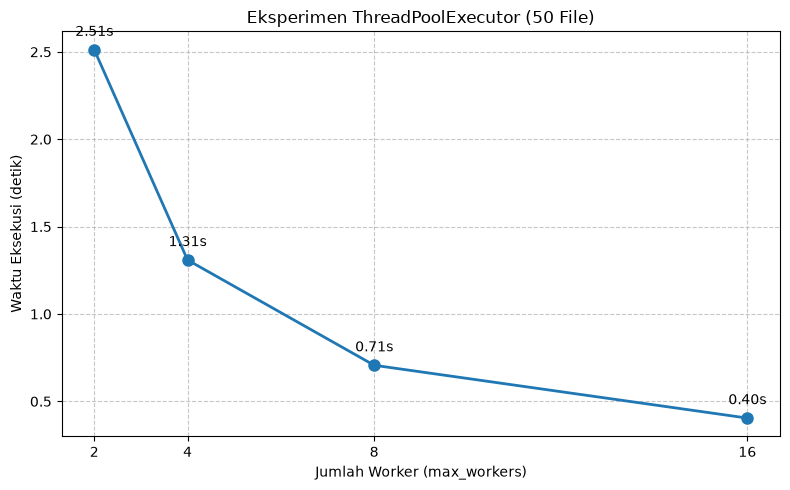

In [7]:
# NO. 3 - EKSPERIMEN THREADPOOLEXECUTOR

import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# 1. JUMLAH FILE DAN WORKER

JUMLAH_FILE = 50
DAFTAR_WORKERS = [2, 4, 8, 16]

# 2. FUNGSI UNTUK MEMPROSES FILE

def proses_file(nomor_file): 
    # Simulasi pekerjaan I/O
    time.sleep(0.1)
    return f"File-{nomor_file} selesai"

# 3. FUNGSI EKSPERIMEN

def jalankan_eksperimen(max_workers):
    daftar_file = range(1, JUMLAH_FILE + 1)
    waktu_mulai = time.perf_counter()
    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:
        hasil = list(
            executor.map(
                proses_file,
                daftar_file
            )
        )
    waktu_selesai = time.perf_counter()
    waktu_eksekusi = waktu_selesai - waktu_mulai
    return waktu_eksekusi

# 4. MENJALANKAN EKSPERIMEN

hasil_waktu = []

print("HASIL EKSPERIMEN")
print("=" * 45)

for workers in DAFTAR_WORKERS:
    
    waktu = jalankan_eksperimen(workers)
    
    hasil_waktu.append(waktu)
    
    print(
        f"max_workers = {workers:2d} "
        f"| waktu = {waktu:.4f} detik"
    )

# 5. MENAMPILKAN TABEL

print("\nTABEL HASIL")
print("-" * 45)
print("max_workers\tWaktu Eksekusi (detik)")

for workers, waktu in zip(
    DAFTAR_WORKERS,
    hasil_waktu
): 
    print(
        f"{workers}\t\t{waktu:.4f}"
    )

# 6. MEMBUAT GRAFIK

plt.figure(figsize=(8, 5))
plt.plot(
    DAFTAR_WORKERS,
    hasil_waktu,
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=8
)
plt.title(
    "Eksperimen ThreadPoolExecutor (50 File)"
)
plt.xlabel(
    "Jumlah Worker (max_workers)"
)
plt.ylabel(
    "Waktu Eksekusi (detik)"
)
plt.xticks(DAFTAR_WORKERS)
plt.grid(
    True,
    linestyle='--',
    alpha=0.7
)

# Menampilkan nilai waktu pada grafik
for x, y in zip(
    DAFTAR_WORKERS,
    hasil_waktu
):  
    plt.annotate(
        f"{y:.2f}s",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )
plt.tight_layout()
plt.show()

Titik jenuh terjadi karena penambahan jumlah thread tidak selalu membuat proses semakin cepat. Pada awalnya, ketika max_workers ditambah dari 2 menjadi 4 atau 8, lebih banyak tugas dapat dikerjakan secara bersamaan sehingga waktu eksekusi menjadi lebih singkat. Namun, setelah jumlah thread semakin banyak, komputer memiliki keterbatasan sumber daya seperti CPU, memori, dan kemampuan I/O. Thread yang terlalu banyak juga membutuhkan overhead untuk dibuat, dijadwalkan, dan dikelola oleh sistem operasi. Akibatnya, penambahan thread setelah jumlah tertentu hanya memberikan sedikit peningkatan atau bahkan dapat membuat proses lebih lambat. Kondisi ketika penambahan jumlah thread tidak lagi memberikan peningkatan performa yang signifikan inilah yang disebut titik jenuh (saturation point).

4. Refleksi Singkat
   
Contoh kasus threading Python membantu:
Threading Python akan membantu pada pekerjaan yang banyak menunggu proses I/O, seperti mengunduh beberapa file atau mengambil data dari beberapa API secara bersamaan. Saat satu thread sedang menunggu respons dari jaringan, thread lain dapat menjalankan tugas lainnya sehingga waktu tunggu dapat dimanfaatkan dan proses menjadi lebih efisien.

Contoh kasus threading Python tidak banyak membantu:
Threading Python tidak banyak membantu pada pekerjaan yang membutuhkan perhitungan CPU yang berat, seperti perhitungan matematis kompleks, pengolahan data dalam jumlah besar, atau pemrosesan gambar yang berat. Pada kasus seperti ini, lebih baik menggunakan multiprocessing karena pekerjaan dapat dijalankan pada beberapa proses dan memanfaatkan beberapa core CPU.